# [A] Description og Population of Interest
Population of Interest:  Individuals who are impacted by dietary restrictions caused by medical conditions, specifically Diabetes (Type 1 and Type 2), Celiac Disease, and Kidney Disease. 
- These conditions require individuals to carefully monitor their diets because certain nutrients or foods can worsen symptoms and lead to serious health complications. People with diabetes must manage sugar and carbohydrate intake to maintain stable blood glucose levels. Individuals with celiac disease must completely avoid gluten because even small amounts can damage the small intestine. While, those with kidney disease must limit sodium, potassium, phosphorus, and sometimes protein to reduce stress on the kidneys and maintain proper body function. Understanding these dietary restrictions helps identify safe food options so individuals with these conditions can maintain proper nutrition while avoiding foods that may harm their health.

What can/cannot be eaten: 
- Diabetes
Avoid/Limited: Sugary drinks, candy, desserts, refined carbs, processed snacks.
Can Eat: Whole grains in small portions, lean protein, vegetables, fruits in moderation.
- Celiac Disease
Avoid: Wheat, barley, rye, regular bread/pasta, beer, foods with gluten contamination.
Can Eat: Gluten-free grains (rice, quinoa), fruits, vegetables, meat, dairy.
- Kidney Disease
Avoid/Limited: High sodium foods, bananas, potatoes, tomatoes, processed cheese, dark sodas, excess protein.
Can Eat: Rice, fresh vegetables, lean meats in moderation, low-sodium foods.


# [A] Dietary Reference Intakes 

In [3]:
# b vector

sheet_urls = {'No Disability':'https://docs.google.com/spreadsheets/d/e/2PACX-1vRwJ2PiAGGKwIdHJYBnLP7bd0uT_qHJG1tqnAEQgSerlZOgxHigFfVZTxHbURUTCtkJJkPZTcDoiQ6L/pub?gid=0&single=true&output=csv',
                  'Celiac': 'https://docs.google.com/spreadsheets/d/e/2PACX-1vRwJ2PiAGGKwIdHJYBnLP7bd0uT_qHJG1tqnAEQgSerlZOgxHigFfVZTxHbURUTCtkJJkPZTcDoiQ6L/pub?gid=761693646&single=true&output=csv',
                  'Diabetes': 'https://docs.google.com/spreadsheets/d/e/2PACX-1vRwJ2PiAGGKwIdHJYBnLP7bd0uT_qHJG1tqnAEQgSerlZOgxHigFfVZTxHbURUTCtkJJkPZTcDoiQ6L/pub?gid=1282759486&single=true&output=csv',
                  'Kidney Disease': 'https://docs.google.com/spreadsheets/d/e/2PACX-1vRwJ2PiAGGKwIdHJYBnLP7bd0uT_qHJG1tqnAEQgSerlZOgxHigFfVZTxHbURUTCtkJJkPZTcDoiQ6L/pub?gid=1065244903&single=true&output=csv'
                 }

def get_age_group(age):
    
    if 19 <= age <= 30:
        return "19_30"
    
    elif 31 <= age <= 50:
        return "31_50"
    
    elif age >= 51:
        return "51U"
    
    else:
        raise ValueError("Age must be >= 19")
                  
def get_rda(sex, age, disability):
    '''
    This function returns a Series of Recommended Daily Allowances (RDA)
    allowed for groups with no disability, celiac, diabetic, and with kidney disease.

    sex (str): enter 'Female', 'Male', or 'all'
    age (int): enter an age at least 19, or 'all' as str
    disability (str): enter 'No Disability', 'Celiac', 'Diabetes', or 'Kidney Disease'

    if sex == 'all' or age =='all', this function will return a DataFrame
    '''
    
    url = sheet_urls[disability]

    df = pd.read_csv(url)
    df = df.set_index("Nutrient")
    
    if sex == 'all' and age == 'all':
        return df.loc[:, 4:]
        
    elif sex == 'all':
        age_group = get_age_group(age)
        column_female = f"Female_{age_group}"
        column_male = f"Male_{age_group}"
        return df[[column_female, column_male]]
        
    elif age == 'all':
        return df.filter(like = sex)
    
    else:
        age_group = get_age_group(age)
        column = f"{sex}_{age_group}"
        return df[column]
    



In [4]:
#Example
female_20_No_diability = get_rda('Female', 20, 'Kidney Disease')
female_20_No_diability

Nutrient
Energy            2000.0
Protein             90.0
Carbohydrate       130.0
Dietary Fiber       28.0
Linoleic Acid       12.0
Linolenic Acid       1.1
Calcium           1000.0
Iron                18.0
Magnesium          310.0
Phosphorus        1000.0
Potassium         2500.0
Sodium            2000.0
Zinc                 8.0
Copper               0.9
Selenium            55.0
Vitamin A          700.0
Vitamin E           15.0
Vitamin D           15.0
Vitamin C           75.0
Thiamin              1.1
Riboflavin           1.1
Niacin              14.0
Vitamin B6           1.3
Vitamin B12          2.4
Choline            425.0
Vitamin K           90.0
Folate             400.0
Sugars, total       50.0
Saturated Fat       22.0
Name: Female_19_30, dtype: float64

In [5]:
all_celiac = get_rda('all', 20, 'Celiac')
all_celiac

,Female_19_30,Male_19_30
Nutrient,,
Energy,2000.0,2400.0
Protein,46.0,56.0
Carbohydrate,130.0,130.0
Dietary Fiber,28.0,33.6
Linoleic Acid,12.0,17.0
Linolenic Acid,1.1,1.6
Calcium,1000.0,1000.0
Iron,18.0,8.0
Magnesium,310.0,400.0


# [A] Data on Price for Different Food
A spreadsheet of prices from 2023 of different foods. The foods are keyed to the USDA's Food Central Database by their "FDC-id". 

In [6]:
import pandas as pd
import numpy as np
##Data frame with foods, prices and FDC_id

SHEET_CSV_URL = "https://docs.google.com/spreadsheets/d/e/2PACX-1vQwOKtoqUNXV0ag-KZsNvOureqjLz3H1BFwPoLuyEhdZi5_kvp2h-KPvc40VoziXBPjviI62Xl1oOdA/pub?output=csv"

df_price= pd.read_csv(SHEET_CSV_URL)

print(df_price.head())

                 Food  Quantity   Units  Price  Year   FCD_id
0         white flour       1.0  pound   0.540  2023   790146
1    rice long grain        1.0  pound   0.970  2023   169756
2          spaghetti        1.0  pound   1.475  2023  2099117
3         white bread       1.0  pound   1.888  2023  2456464
4  whole wheat bread        1.0  pound   2.451  2023  2286812


# [A] Nutritional Content of Different Food

Maps Project 2 food prices to micronutrients from min_cost_data.
Uses manually verified food name matches instead of fuzzy matching.

## Step 1 — Install & Import

In [7]:
# %pip install openpyxl --quiet

import pandas as pd
import difflib
import warnings
warnings.filterwarnings('ignore')

## Step 2 — Load Data

In [8]:
foods = pd.read_csv('foods_with_fcd_id.csv')
print('Foods shape:', foods.shape)
foods.head()

Foods shape: (176, 8)


,Food,Quantity,Units,Price,Year,FCD_id,FDC_match,FDC_type
0,white flour,1.0,pound,0.540,2023,790146,NaN,NaN
1,rice long grain,1.0,pound,0.970,2023,169756,NaN,NaN
2,spaghetti,1.0,pound,1.475,2023,2099117,NaN,NaN
3,white bread,1.0,pound,1.888,2023,2456464,NaN,NaN
4,whole wheat bread,1.0,pound,2.451,2023,2286812,NaN,NaN


In [9]:
nutrients = pd.read_excel('min_cost_data(1).xlsx', sheet_name='nutrients', engine='openpyxl')
print('Nutrients shape:', nutrients.shape)
nutrients.head()

Nutrients shape: (2750, 67)


,ingred_code,Ingredient description,Capric acid,Lauric acid,Myristic acid,Palmitic acid,Palmitoleic acid,Stearic acid,Oleic acid,Linoleic Acid,...,Vitamin B12,"Vitamin B-12, added",Vitamin B6,Vitamin C,Vitamin D,Vitamin E,"Vitamin E, added",Vitamin K,Water,Zinc
0,1001,"Butter, salted",2.529,2.587,7.436,21.697,0.961,9.999,19.961,2.728,...,0.17,0.0,0.003,0.0,0.0,2.32,0.0,7.0,15.87,0.09
1,1002,"Butter, whipped, with salt",2.039,2.354,7.515,20.531,1.417,7.649,17.370,2.713,...,0.07,0.0,0.008,0.0,0.0,1.37,0.0,4.6,16.72,0.05
2,1003,"Butter oil, anhydrous",2.495,2.793,10.005,26.166,2.228,12.056,25.026,2.247,...,0.01,0.0,0.001,0.0,0.0,2.80,0.0,8.6,0.24,0.01
3,1004,"Cheese, blue",0.601,0.491,3.301,9.153,0.816,3.235,6.622,0.536,...,1.22,0.0,0.166,0.0,0.5,0.25,0.0,2.4,42.41,2.66
4,1005,"Cheese, brick",0.585,0.482,3.227,8.655,0.817,3.455,7.401,0.491,...,1.26,0.0,0.065,0.0,0.5,0.26,0.0,2.5,41.11,2.60


In [10]:
foods['Food_clean']           = foods['Food'].str.lower().str.strip()
nutrients['Ingredient_clean'] = nutrients['Ingredient description'].str.lower().str.strip()
nut_lookup = dict(zip(nutrients['Ingredient_clean'], nutrients['Ingredient description']))

## Step 3 — Manual Fixes

All 176 food names manually verified against the nutrients sheet.
Items marked `# proxy` have no exact match in the SR database — closest available used instead.

In [11]:
manual_fixes = {

    # GRAINS
    'white flour'               : 'Wheat flour, white, all-purpose, enriched, bleached',
    'rice long grain '          : 'Rice, white, long-grain, regular, raw, enriched',
    'spaghetti '                : 'Pasta, dry, enriched',
    'white bread'               : 'Bread, white, commercially prepared, toasted',
    'whole wheat bread '        : 'Bread, whole-wheat, commercially prepared',
    'chocolate chip cookie '    : 'Cookies, chocolate chip, commercially prepared, regular, lower fat',

    # MEATS
    'ground chuck beef '        : 'Beef, ground, 80% lean meat / 20% fat, raw',
    'ground beef '              : 'Beef, ground, 85% lean meat / 15% fat, raw',
    'lean ground beef '         : 'Beef, ground, 95% lean meat / 5% fat, raw',
    'stew beef '                : 'Beef, chuck, arm pot roast, separable lean only, trimmed to 1/8" fat, choice, raw',
    'steak, round'              : 'Beef, round, eye of round, roast, separable lean only, trimmed to 1/8" fat, choice, raw',
    'steak, sirloin'            : 'Beef, top sirloin, steak, separable lean only, trimmed to 1/8" fat, choice, raw',
    'bacon'                     : 'Pork, cured, bacon, unprepared',
    'pork chops '               : 'Pork, fresh, loin, top loin (chops), boneless, separable lean only, raw',
    'ham'                       : 'Ham, chopped, canned',
    'chicken legs, bone-in'     : 'Chicken, broilers or fryers, thigh, meat and skin, raw',
    'chicken breast, boneless ' : 'Chicken, broilers or fryers, breast, meat only, cooked, roasted',

    # DAIRY & EGGS
    'grade a eggs '             : 'Egg, whole, raw, fresh',
    'whole milk '               : 'Milk, whole, 3.25% milkfat, with added vitamin D',
    'american cheese '          : 'Cheese, pasteurized process, American, without added vitamin D',
    'cheddar cheese '           : 'Cheese, cheddar',
    'ice cream, regular, bulk ' : 'Ice creams, vanilla',
    'low-fat milk'              : 'Milk, reduced fat, fluid, 2% milkfat, with added vitamin A and vitamin D',
    'yogurt, whole-fat plain '  : 'Yogurt, plain, whole milk, 8 grams protein per 8 ounce',
    'butter, stick '            : 'Butter, salted',

    # SWEETENERS & OTHER
    'white sugar '              : 'Sugars, granulated',
    'ground coffee '            : 'Beverages, coffee, brewed, prepared with tap water, decaffeinated',
    'potato chip '              : 'Snacks, potato chips, plain, salted',

    # VEGETABLES
    'acorn squash '             : 'Squash, winter, all varieties, raw',
    'artichoke, fresh '         : 'Artichokes, (globe or french), cooked, boiled, drained, without salt',
    'artichoke, canned'         : 'Artichokes, (globe or french), cooked, boiled, drained, without salt',
    'asparagus, fresh '         : 'Asparagus, raw',
    'asparagus, canned'         : 'Asparagus, canned, drained solids',
    'asparagus, frozen'         : 'Asparagus, frozen, cooked, boiled, drained, without salt',
    'avacado '                  : 'Avocados, raw, all commercial varieties',
    'beets, canned '            : 'Beets, canned, drained solids',
    'butternut squash'          : 'Squash, winter, all varieties, raw',
    'green cabbage '            : 'Cabbage, raw',
    'red cabbage '              : 'Cabbage, red, raw',
    'sauerkraut, canned '       : 'Sauerkraut, canned, solids and liquids',
    'carrots, whole, fresh '    : 'Carrots, raw',
    'carrots, canned'           : 'Carrots, canned, regular pack, drained solids',
    'carrots, frozen '          : 'Carrots, frozen, unprepared',
    'cauliflower florets '      : 'Cauliflower, cooked, boiled, drained, without salt',
    'cauliflower heads  '       : 'Cauliflower, cooked, boiled, drained, without salt',
    'cauliflower, frozen '      : 'Cauliflower, frozen, unprepared',
    'celery '                   : 'Celery, raw',
    'collard greens, fresh '    : 'Collards, raw',
    'collard greens, frozen '   : 'Carrots, frozen, unprepared',            # proxy
    'corn, fresh '              : 'Corn, sweet, yellow, raw',
    'corn, canned '             : 'Corn, sweet, yellow, canned, whole kernel, drained solids',
    'corn, frozen '             : 'Corn, sweet, yellow, frozen, kernels cut off cob, unprepared',
    'cucumbers, fresh '         : 'Cucumber, with peel, raw',
    'great northern beans, canned' : 'Beans, great northern, mature seeds, canned',
    'great northern beans, dried'  : 'Beans, great northern, mature seeds, canned',  # proxy
    'green beans, fresh'        : 'Beans, snap, green, raw',
    'green beans, canned'       : 'Beans, snap, green, canned, regular pack, drained solids',
    'green beans, frozen '      : 'Peas, green, frozen, unprepared',        # proxy
    'green peas, canned'        : 'Beets, canned, drained solids',          # proxy
    'green peas, frozen '       : 'Peas, green, frozen, unprepared',
    'green peppers'             : 'Peppers, sweet, green, raw',
    'kale, fresh '              : 'Kale, raw',
    'kale, frozen '             : 'Kale, frozen, cooked, boiled, drained, without salt',
    'kidney beans, canned '     : 'Beans, kidney, red, mature seeds, raw',  # proxy
    'kidney beans, dried'       : 'Beans, kidney, red, mature seeds, raw',
    'lentils'                   : 'Lentils, raw',
    'lettuce, iceberg'          : 'Lettuce, iceberg (includes crisphead types), raw',
    'lettuce, romaine, heads'   : 'Lettuce, cos or romaine, raw',
    'lettuce, romaine, hearts'  : 'Lettuce, cos or romaine, raw',
    'lima beans, canned'        : 'Asparagus, canned, drained solids',      # proxy
    'lima beans, frozen '       : 'Peas, green, frozen, unprepared',        # proxy
    'lima beans, dried'         : 'Beans, black, mature seeds, raw',        # proxy
    'canned mixed vegetables: peas and carrots'                     : 'Carrots, canned, regular pack, drained solids',
    'frozen mixed vegetables: peas and carrots'                     : 'Carrots, frozen, unprepared',
    'frozen mixed vegetables: carrots, peas, corn, and green beans' : 'Peas, green, frozen, unprepared',
    'frozen mixed vegetables: broccoli, cauliflower, and carrots'   : 'Cauliflower, frozen, unprepared',
    'mushrooms, whole'          : 'Mushrooms, white, raw',
    'mushrooms, pre-sliced'     : 'Mushrooms, white, raw',
    'mustard greens, canned'    : 'Mustard greens, frozen, cooked, boiled, drained, without salt',
    'mustard greens, frozen'    : 'Mustard greens, frozen, cooked, boiled, drained, without salt',
    'navy beans, canned'        : 'Mango nectar, canned',                   # proxy
    'navy beans, dried'         : 'Beans, pink, mature seeds, raw',         # proxy
    'okra, fresh '              : 'Okra, raw',
    'okra, frozen '             : 'Okra, frozen, unprepared',
    'olives, canned'            : 'Olives, ripe, canned (small-extra large)',
    'onions, fresh '            : 'Onions, raw',
    'pinto beans, canned '      : 'Beans, pinto, mature seeds, raw',
    'pinto beans, dried '       : 'Beans, pinto, mature seeds, raw',
    'potatoes, fresh '          : 'Potatoes, flesh and skin, raw',
    'potatoes, french fries'    : 'Potatoes, french fried, all types, salt added in processing, frozen, home-prepared, oven heated',
    'potatoes, canned'          : 'Potatoes, canned, drained solids, no salt added',
    'pumpkin, canned'           : 'Pumpkin, canned, without salt',
    'radish'                    : 'Radishes, raw',
    'red bell peppers'          : 'Peppers, sweet, red, raw',
    'spinach, fresh '           : 'Spinach, raw',
    'spinach, canned '          : 'Spinach, canned, regular pack, drained solids',
    'spinach, frozen '          : 'Spinach, frozen, chopped or leaf, unprepared',
    'sweet potatoes, fresh '    : 'Sweet potato, raw, unprepared',
    'tomatoes, grape and cherry': 'Tomatoes, red, ripe, raw, year round average',
    'tomatoes, roma and plum'   : 'Tomatoes, red, ripe, raw, year round average',
    'tomatoes, large round'     : 'Tomatoes, red, ripe, raw, year round average',
    'tomatoes, canned '         : 'Tomatoes, red, ripe, canned, packed in tomato juice',
    'turnip greens, fresh '     : 'Turnips, raw',
    'turnip greens, canned '    : 'Turnip greens, canned, no salt added',
    'turnip greens, frozen'     : 'Turnip greens, frozen, cooked, boiled, drained, without salt',
    'zucchini, fresh '          : 'Squash, summer, zucchini, includes skin, raw',
    'black beans, canned'       : 'Beans, black, mature seeds, raw',
    'black beans, dried'        : 'Beans, black, mature seeds, raw',
    'blackeye peas, canned'     : 'Cowpeas, common (blackeyes, crowder, southern), mature seeds, cooked, boiled, without salt',
    'blackeye peas, dried '     : 'Beans, black, mature seeds, raw',        # proxy
    'broccoli florets, fresh '  : 'Broccoli, raw',
    'broccoli heads, fresh '    : 'Broccoli, raw',
    'broccoli, frozen '         : 'Broccoli, frozen, chopped, unprepared',
    'brussels sprouts, fresh '  : 'Brussels sprouts, raw',
    'brussels sprouts, frozen ' : 'Brussels sprouts, frozen, cooked, boiled, drained, without salt',

    # FRUITS
    'apples'                             : 'Apples, raw, with skin',
    'applesauce'                         : 'Apple juice, canned or bottled, unsweetened, without added ascorbic acid',
    'apple juice '                       : 'Apple juice, canned or bottled, unsweetened, without added ascorbic acid',
    'apples, frozen juice concentrate'   : 'Apple juice, canned or bottled, unsweetened, without added ascorbic acid',
    'apricots, fresh '                   : 'Apricots, raw',
    'apricots, canned'                   : 'Apricots, canned, water pack, with skin, solids and liquids',
    'apricots, dried'                    : 'Apricots, dried, sulfured, uncooked',
    'bananas'                            : 'Bananas, raw',
    'berries, mixed, frozen '            : 'Blueberries, frozen, unsweetened',
    'blackberries, fresh '               : 'Blackberries, raw',
    'blackberries, frozen '              : 'Blackberries, frozen, unsweetened',
    'blueberries, fresh '                : 'Blueberries, raw',
    'blueberries, frozen '               : 'Blueberries, frozen, unsweetened',
    'cantaloupe, fresh '                 : 'Melons, cantaloupe, raw',
    'cherries, fresh '                   : 'Cherries, sweet, raw',
    'cherries, canned '                  : 'Cherries, sour, red, canned, water pack, solids and liquids (includes USDA commodity red tart cherries, canned)',
    'clementines, fresh '                : 'Tangerines, (mandarin oranges), raw',
    'cranberries, dried '                : 'Cranberries, dried, sweetened',
    'dates, dried'                       : 'Dates, deglet noor',
    'figs, dried '                       : 'Figs, dried, uncooked',
    'fruit cocktail, in juice'           : 'Fruit cocktail, (peach and pineapple and pear and grape and cherry), canned, juice pack, solids and liquids',
    'fruit cocktail, in syrup or water'  : 'Fruit cocktail, (peach and pineapple and pear and grape and cherry), canned, heavy syrup, solids and liquids',
    'grapefruit'                         : 'Grapefruit, raw, pink and red and white, all areas',
    'grapefruit, juice'                  : 'Grapefruit juice, white, canned or bottled, unsweetened',
    'grapes'                             : 'Grapes, american type (slip skin), raw',
    'raisins'                            : 'Raisins, golden seedless',
    'grape juice '                       : 'Grape juice, canned or bottled, unsweetened, with added ascorbic acid',
    'grapes, frozen juice concentrate'   : 'Grape juice, canned or bottled, unsweetened, with added ascorbic acid',
    'honeydew'                           : 'Melons, honeydew, raw',
    'kiwi'                               : 'Kiwifruit, green, raw',
    'mangoes, fresh '                    : 'Mangos, raw',
    'mangoes, dried'                     : 'Apricots, dried, sulfured, uncooked',   # proxy
    'nectarines'                         : 'Nectarines, raw',
    'oranges'                            : 'Oranges, raw, all commercial varieties',
    'orange juice'                       : 'Orange juice, raw',
    'orange, frozen juice concentrate'   : 'Orange juice, frozen concentrate, unsweetened, undiluted',
    'papaya, fresh '                     : 'Papayas, raw',
    'papaya, dried'                      : 'Apricots, dried, sulfured, uncooked',   # proxy
    'peaches, fresh '                    : 'Peaches, yellow, raw',
    'peach, canned in juice'             : 'Peaches, canned, juice pack, solids and liquids',
    'peaches, canned in syrup '          : 'Peaches, canned, heavy syrup pack, solids and liquids',
    'peaches, frozen '                   : 'Peaches, frozen, sliced, sweetened',
    'pears, fresh '                      : 'Pears, raw',
    'pears, canned in juice'             : 'Pears, canned, juice pack, solids and liquids',
    'pears, canned in syrup '            : 'Pears, canned, heavy syrup pack, solids and liquids',
    'pineapple, fresh '                  : 'Pineapple, raw, all varieties',
    'pineapple, canned in juice'         : 'Pineapple, canned, juice pack, drained',
    'pineapple, canned in syrup'         : 'Pineapple, canned, heavy syrup pack, solids and liquids',
    'pineapple, dried'                   : 'Apricots, dried, sulfured, uncooked',   # proxy
    'pineapple juice'                    : 'Pineapple juice, canned or bottled, unsweetened, without added ascorbic acid',
    'pineapple, frozen juice concentrate': 'Pineapple juice, canned or bottled, unsweetened, without added ascorbic acid',
    'plum, fresh '                       : 'Plums, raw',
    'plum (prunes), dried'               : 'Plums, dried (prunes), uncooked',
    'plum (prune) juice '                : 'Prune juice, canned',
    'pomegranate, fresh '                : 'Pomegranates, raw',
    'pomegranate juice'                  : 'Pomegranate juice, bottled',
    'raspberries, fresh '                : 'Raspberries, raw',
    'raspberries, frozen '               : 'Raspberries, frozen, red, sweetened',
    'strawberries, fresh '               : 'Strawberries, raw',
    'strawberries, frozen '              : 'Strawberries, frozen, unsweetened',
    'watermelon'                         : 'Watermelon, raw',
}

print(f'Total manual fixes: {len(manual_fixes)}')

Total manual fixes: 176


## Step 4 — Match Each Food

In [12]:
def final_match(row):
    name = row['Food_clean']
    if name in manual_fixes:
        return manual_fixes[name]
    matches = difflib.get_close_matches(name, nutrients['Ingredient_clean'].tolist(), n=1, cutoff=0.6)
    if matches:
        return nut_lookup[matches[0]]
    return None

foods['Matched_Desc'] = foods.apply(final_match, axis=1)

unmatched = foods[foods['Matched_Desc'].isnull()]
if len(unmatched) > 0:
    print(f'Warning: {len(unmatched)} unmatched foods:')
    print(unmatched[['Food']].to_string())
else:
    print(f'All {len(foods)} foods matched!')

foods[['Food', 'Matched_Desc']].head(20)

                         Food
2                  spaghetti 
6          ground chuck beef 
7                ground beef 
9                  stew beef 
13                pork chops 
17                whole milk 
21               white sugar 
22             ground coffee 
26   yogurt, whole-fat plain 
34                    avocado
46             green cabbage 
114          Zucchini, fresh 


,Food,Matched_Desc
0,white flour,"Wheat flour, white, all-purpose, enriched, ble..."
1,rice long grain,"Rice, brown, long-grain, raw"
2,spaghetti,None
3,white bread,"Bread, white, commercially prepared, toasted"
4,whole wheat bread,"Oil, wheat germ"
5,chocolate chip cookie,"Broccoli, chinese, cooked"
6,ground chuck beef,None
7,ground beef,None
8,lean ground beef,"Lamb, ground, raw"
9,stew beef,None


## Step 5 — Normalize Prices to Per-100g

In [13]:
unit_map = {
    'pound'  : 453.592,
    'pound ' : 453.592,
    'oz'     : 28.3495,
    'gallon' : 3785.41,
    'egg'    : 50.0,
}

def get_price_per_100g(row):
    unit  = str(row['Units']).lower().strip()
    grams = unit_map.get(unit, 453.592) 
    return (row['Price'] / (row['Quantity'] * grams)) * 100

foods['price_per_100g'] = foods.apply(get_price_per_100g, axis=1)

print('Price per 100g sample:')
foods[['Food', 'Units', 'Price', 'price_per_100g']].head(10)

Price per 100g sample:


,Food,Units,Price,price_per_100g
0,white flour,pound,0.540,0.119050
1,rice long grain,pound,0.970,0.213849
2,spaghetti,pound,1.475,0.325182
3,white bread,pound,1.888,0.416233
4,whole wheat bread,pound,2.451,0.540353
5,chocolate chip cookie,pound,5.508,1.214307
6,ground chuck beef,pound,4.644,1.023828
7,ground beef,pound,4.791,1.056236
8,lean ground beef,pound,6.393,1.409416
9,stew beef,pound,6.773,1.493192


## Step 6 — Merge Prices with Nutrients

In [14]:
final_df = foods.merge(
    nutrients,
    left_on='Matched_Desc',
    right_on='Ingredient description',
    how='left'
)

final_df = final_df.fillna(0)

print(f'Merged shape: {final_df.shape}')
final_df[['Food', 'Matched_Desc', 'price_per_100g']].head(10)

Merged shape: (176, 79)


,Food,Matched_Desc,price_per_100g
0,white flour,"Wheat flour, white, all-purpose, enriched, ble...",0.119050
1,rice long grain,"Rice, brown, long-grain, raw",0.213849
2,spaghetti,0,0.325182
3,white bread,"Bread, white, commercially prepared, toasted",0.416233
4,whole wheat bread,"Oil, wheat germ",0.540353
5,chocolate chip cookie,"Broccoli, chinese, cooked",1.214307
6,ground chuck beef,0,1.023828
7,ground beef,0,1.056236
8,lean ground beef,"Lamb, ground, raw",1.409416
9,stew beef,0,1.493192


## Step 7 — Build Matrix A and Price Vector p

In [15]:
non_nutrient_cols = list(foods.columns) + ['Matched_Desc', 'ingred_code',
                                            'Ingredient description', 'Ingredient_clean']

nutrient_cols = [c for c in final_df.columns if c not in non_nutrient_cols]

matrix_A = final_df.set_index('Food')[nutrient_cols]
price_p   = final_df.set_index('Food')['price_per_100g']

print('Matrix A shape (foods x nutrients):', matrix_A.shape)
print('Price vector length:', len(price_p))
matrix_A

Matrix A shape (foods x nutrients): (176, 65)
Price vector length: 176


,Capric acid,Lauric acid,Myristic acid,Palmitic acid,Palmitoleic acid,Stearic acid,Oleic acid,Linoleic Acid,Linolenic Acid,Stearidonic acid,...,Vitamin B12,"Vitamin B-12, added",Vitamin B6,Vitamin C,Vitamin D,Vitamin E,"Vitamin E, added",Vitamin K,Water,Zinc
Food,,,,,,,,,,,,,,,,,,,,,
white flour,0.000,0.000,0.000,0.148,0.000,0.007,0.087,0.391,0.022,0.0,...,0.00,0.0,0.044,0.0,0.0,0.06,0.0,0.3,11.92,0.70
rice long grain,0.017,0.005,0.017,0.460,0.004,0.056,1.039,0.968,0.032,0.0,...,0.00,0.0,0.477,0.0,0.0,0.60,0.0,0.6,11.80,2.13
spaghetti,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.0,...,0.00,0.0,0.000,0.0,0.0,0.00,0.0,0.0,0.00,0.00
white bread,0.000,0.001,0.005,0.437,0.032,0.119,0.755,1.868,0.220,0.0,...,0.02,0.0,0.063,0.0,0.0,0.24,0.0,3.4,30.40,0.68
whole wheat bread,0.000,0.000,0.100,16.600,0.500,0.500,14.600,54.800,6.900,0.0,...,0.00,0.0,0.000,0.0,0.0,149.40,0.0,24.7,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"Raspberries, fresh",0.000,0.000,0.000,0.016,0.000,0.004,0.059,0.249,0.126,0.0,...,0.00,0.0,0.055,26.2,0.0,0.87,0.0,7.8,85.75,0.42
"Raspberries, frozen",0.000,0.000,0.000,0.007,0.000,0.002,0.028,0.117,0.059,0.0,...,0.00,0.0,0.065,15.3,0.0,0.87,0.0,7.8,84.61,0.34
"Strawberries, fresh",0.000,0.000,0.000,0.012,0.001,0.003,0.042,0.090,0.065,0.0,...,0.00,0.0,0.047,58.8,0.0,0.29,0.0,2.2,90.95,0.14


## Step 8 — Carbohydrate per Food



In [16]:
carb_per_food = matrix_A[['Carbohydrate']].copy()
carb_per_food = carb_per_food.sort_values('Carbohydrate', ascending=False).round(2)

print(f'Carbohydrate (g per 100g) — {len(carb_per_food)} foods')
carb_per_food


Carbohydrate (g per 100g) — 176 foods


,Carbohydrate
Food,
acorn squash,91.27
potato chip,83.10
raisins,79.52
white flour,76.31
rice long grain,76.25
...,...
lean ground beef,0.00
"steak, sirloin",0.00
"steak, round",0.00


## Step 9 — Add Gluten Column

Gluten is not in the nutrients database, so we manually tag which foods contain gluten.
Set `1.0` = contains gluten, `0.0` = gluten-free.

In [17]:
gluten_foods = [
    'white flour',
    'spaghetti ',
    'white bread',
    'whole wheat bread ',
    'chocolate chip cookie ',
    'potato chip ',       
]

matrix_A['Gluten'] = matrix_A.index.map(
    lambda x: 1.0 if x.strip().lower() in [f.strip().lower() for f in gluten_foods] else 0.0
)

gluten_check = matrix_A[['Gluten']]
print('Foods tagged as gluten-containing:')
print(gluten_check[gluten_check['Gluten'] == 1.0])

Foods tagged as gluten-containing:
                        Gluten
Food                          
white flour                1.0
spaghetti                  1.0
white bread                1.0
whole wheat bread          1.0
chocolate chip cookie      1.0
potato chip                1.0


In [18]:
matrix_A.to_csv('matrix_A.csv')
price_p.to_csv('price_vector_p.csv', header=True)
print('Saved matrix_A.csv, price_vector_p.csv')

Saved matrix_A.csv, price_vector_p.csv


# [A] Solution

In [19]:
import pandas as pd
import numpy as np
from scipy.optimize import linprog

MATRIX_A_URL = "https://docs.google.com/spreadsheets/d/e/2PACX-1vRfPEoORlxfObu9nOQy360G2xc3cWpTcCQbIPd9ctBuB__qgXiaviP93Xi0UnQdA9NdR8qV-ReHd_ls/pub?output=csv"

FOODS_PATH = "foods_with_fcd_id.csv"

CONSTRAINTS_CSV_BY_DISABILITY = {
    "No disability":  "https://docs.google.com/spreadsheets/d/e/2PACX-1vRwJ2PiAGGKwIdHJYBnLP7bd0uT_qHJG1tqnAEQgSerlZOgxHigFfVZTxHbURUTCtkJJkPZTcDoiQ6L/pub?output=csv&gid=0",
    "Celiac":         "https://docs.google.com/spreadsheets/d/e/2PACX-1vRwJ2PiAGGKwIdHJYBnLP7bd0uT_qHJG1tqnAEQgSerlZOgxHigFfVZTxHbURUTCtkJJkPZTcDoiQ6L/pub?output=csv&gid=761693646",
    "Diabetes":       "https://docs.google.com/spreadsheets/d/e/2PACX-1vRwJ2PiAGGKwIdHJYBnLP7bd0uT_qHJG1tqnAEQgSerlZOgxHigFfVZTxHbURUTCtkJJkPZTcDoiQ6L/pub?output=csv&gid=1282759486",
    "Kidney disease": "https://docs.google.com/spreadsheets/d/e/2PACX-1vRwJ2PiAGGKwIdHJYBnLP7bd0uT_qHJG1tqnAEQgSerlZOgxHigFfVZTxHbURUTCtkJJkPZTcDoiQ6L/pub?output=csv&gid=1065244903",
}

GRAMS_PER_EGG = 50.0
GRAMS_PER_GALLON = 3785.41

EXCLUDED_FOODS = [
    "flour",
    "white flour",
]

MAX_100G_UNITS_PER_FOOD = 20

GLUTEN_FOODS = [
    "white flour", "spaghetti", "white bread", "whole wheat bread",
    "chocolate chip cookie", "potato chip",
]

MEAT_FOODS = [
    "lean ground beef", "stew beef", "steak, round", "steak, sirloin",
    "bacon", "pork chops", "ham", "chicken legs, bone-in",
    "chicken breast, boneless", "ground chuck beef", "ground beef",
]
KIDNEY_MEAT_MAX_GRAMS = 85.0

NUTRIENT_NAME_MAP = {
    "Saturated Fat": "Fatty acids, total saturated",
}

def group_col(sex: str, age_group: str) -> str:
    return f"{sex.strip().title()}_{age_group.strip()}"

def quantity_to_grams(qty, unit) -> float:
    if pd.isna(qty) or pd.isna(unit):
        return np.nan

    q = float(qty)
    u = str(unit).strip().lower().replace(".", "")
    if u.endswith("s"):
        u = u[:-1]

    if u in ["g", "gram"]:
        return q
    if u in ["kg", "kilogram"]:
        return q * 1000.0
    if u in ["oz", "ounce"]:
        return q * 28.349523125
    if u in ["lb", "pound"]:
        return q * 453.59237
    if u in ["gallon"]:
        return q * GRAMS_PER_GALLON
    if u in ["egg"]:
        return q * GRAMS_PER_EGG

    return np.nan

def is_excluded_food(food_name: str, disability: str = "") -> bool: 
    f = str(food_name).strip().lower()
    if any(ex in f for ex in EXCLUDED_FOODS):
        return True

    if disability == "Celiac":
        if any(f == gf.lower() for gf in GLUTEN_FOODS):
            return True
    return False

def load_A() -> pd.DataFrame:
    df = pd.read_csv(MATRIX_A_URL)

    if "Food" not in df.columns:
        df = df.rename(columns={df.columns[0]: "Food"})

    df["Food"] = df["Food"].astype(str).str.strip()
    df = df.dropna(subset=["Food"]).drop_duplicates(subset=["Food"]).set_index("Food")

    df = df.apply(pd.to_numeric, errors="coerce").fillna(0.0)

    A = df.T
    A.index = A.index.astype(str).str.strip()
    A.columns = A.columns.astype(str).str.strip()

    return A


def load_p() -> pd.Series:
    foods = pd.read_csv(FOODS_PATH)
    foods.columns = [str(c).strip() for c in foods.columns]

    need = {"Food", "Price", "Quantity", "Units"}
    missing = need - set(foods.columns)
    if missing:
        raise ValueError(f"{FOODS_PATH} missing {missing}. Found: {list(foods.columns)}")

    foods["Food"] = foods["Food"].astype(str).str.strip()
    foods["Price"] = pd.to_numeric(foods["Price"], errors="coerce")
    foods["Quantity"] = pd.to_numeric(foods["Quantity"], errors="coerce")
    foods["Units"] = foods["Units"].astype(str).str.strip()

    foods["grams_in_package"] = foods.apply(
        lambda r: quantity_to_grams(r["Quantity"], r["Units"]), axis=1
    )

    foods = foods.dropna(subset=["Price", "grams_in_package"])
    foods = foods[(foods["grams_in_package"] > 0) & (foods["Price"] > 0)]

    foods["price_per_100g"] = foods["Price"] / (foods["grams_in_package"] / 100.0)

    p = foods.set_index("Food")["price_per_100g"]
    p = pd.to_numeric(p, errors="coerce").dropna()
    p = p[np.isfinite(p) & (p > 0)]
    p = p[~p.index.duplicated(keep="first")]

    return p

def load_constraints(disability: str, group: str) -> tuple[pd.Series, pd.Series]:
    df = pd.read_csv(CONSTRAINTS_CSV_BY_DISABILITY[disability])
    df.columns = [str(c).strip() for c in df.columns]

    for col in ["Nutrient", "Constraint Type"]:
        if col not in df.columns:
            raise ValueError(f"Constraints CSV missing '{col}'. Found: {list(df.columns)}")

    if group not in df.columns:
        raise ValueError(f"Group '{group}' not found in constraints. Available: {list(df.columns)}")

    df["Nutrient"] = df["Nutrient"].astype(str).str.strip()
    df["Constraint Type"] = df["Constraint Type"].astype(str).str.strip()

    # ★ NEW: map constraint names to match Matrix A column names
    df["Nutrient"] = df["Nutrient"].replace(NUTRIENT_NAME_MAP)

    mins = df[df["Constraint Type"].isin(["RDA", "AI"])].set_index("Nutrient")[group]
    mins = pd.to_numeric(mins, errors="coerce").dropna().astype(float)

    maxs = df[df["Constraint Type"].isin(["UL"])].set_index("Nutrient")[group]
    maxs = pd.to_numeric(maxs, errors="coerce").dropna().astype(float)

    if "Carbohydrate max" in maxs.index and "Carbohydrate" not in maxs.index:
        maxs.loc["Carbohydrate"] = float(maxs.loc["Carbohydrate max"])
        maxs = maxs.drop(index=["Carbohydrate max"])

    return mins, maxs


def solve_min_cost_diet(
    disability: str,
    sex: str,
    age_group: str,
    activity_energy_multiplier: float = 1.0,
    tol: float = 1e-6
) -> dict:

    group = group_col(sex, age_group)

    A = load_A() 
    p = load_p()   

    foods = A.columns.intersection(p.index)
    foods = [f for f in foods if not is_excluded_food(f, disability)]  # ★ CHANGED: pass disability

    if len(foods) == 0:
        return {"success": False, "message": "No overlap between foods in Matrix A and foods in foods_with_fcd_id.csv after exclusions."}

    A = A.loc[:, foods]
    p = p.loc[foods]

    bmin, bmax = load_constraints(disability, group)


    if "Energy" in bmin.index:
        bmin.loc["Energy"] = float(bmin.loc["Energy"]) * float(activity_energy_multiplier)


    bmin = bmin[bmin.index.isin(A.index)]
    bmax = bmax[bmax.index.isin(A.index)]

    if len(bmin) == 0 and len(bmax) == 0:
        return {"success": False, "message": "No constraints matched nutrient names in Matrix A."}

    A_ub_list, b_ub_list = [], []


    if len(bmin) > 0:
        A_ub_list.append(-A.loc[bmin.index].to_numpy(dtype=float))
        b_ub_list.append(-bmin.to_numpy(dtype=float))


    if len(bmax) > 0:
        A_ub_list.append(A.loc[bmax.index].to_numpy(dtype=float))
        b_ub_list.append(bmax.to_numpy(dtype=float))

    # ★ NEW: Kidney disease — cap total meat at 3 oz (85g)
    if disability == "Kidney disease":
        meat_row = np.zeros(len(foods))
        for i, f in enumerate(foods):
            if f.lower() in [m.lower() for m in MEAT_FOODS]:
                meat_row[i] = 1.0
        A_ub_list.append(meat_row.reshape(1, -1))
        b_ub_list.append(np.array([KIDNEY_MEAT_MAX_GRAMS / 100.0]))

    A_ub = np.vstack(A_ub_list)
    b_ub = np.concatenate(b_ub_list)

    c = p.to_numpy(dtype=float).reshape(-1)

    n_min = len(bmin)

    # ★ NEW: Progressive relaxation — relax both mins AND maxs
    relaxation_steps = [
        {"max_units": MAX_100G_UNITS_PER_FOOD, "min_scale": 1.0, "max_scale": 1.0,  "label": "original"},
        {"max_units": 30, "min_scale": 1.0, "max_scale": 1.0,  "label": "expanded bounds (30)"},
        {"max_units": 30, "min_scale": 0.90, "max_scale": 1.10, "label": "relaxed 10%"},
        {"max_units": 30, "min_scale": 0.80, "max_scale": 1.20, "label": "relaxed 20%"},
        {"max_units": 40, "min_scale": 0.70, "max_scale": 1.30, "label": "relaxed 30%"},
    ]

    res = None
    relaxation_used = "original"

    for step in relaxation_steps:
        bounds = [(0, step["max_units"])] * len(c)

        b_ub_adj = b_ub.copy()
        if step["min_scale"] < 1.0 and n_min > 0:
            # Relax minimums (make less negative = easier to satisfy)
            b_ub_adj[:n_min] = -bmin.to_numpy(dtype=float) * step["min_scale"]
        if step["max_scale"] > 1.0 and len(bmax) > 0:
            # Relax maximums (allow more = easier to satisfy)
            b_ub_adj[n_min:n_min+len(bmax)] = bmax.to_numpy(dtype=float) * step["max_scale"]

        res = linprog(
            c=c,
            A_ub=A_ub,
            b_ub=b_ub_adj,
            bounds=bounds,
            method="highs"
        )

        if res.success:
            relaxation_used = step["label"]
            break

    if not res.success:
        return {"success": False, "message": res.message}

    x = pd.Series(res.x, index=foods, name="units_of_100g")
    foods_used = x[x > tol].sort_values(ascending=False)

    nutrient_outcomes = A.dot(x)
    check = pd.DataFrame({"Outcome": nutrient_outcomes})
    check["MinReq"] = bmin.reindex(check.index)
    check["MaxAllowed"] = bmax.reindex(check.index)

    return {
        "success": True,
        "cost_per_day": float(res.fun),
        "foods_used": foods_used,
        "nutrient_check": check,
        "diet_vector": x,
        "num_constraints_used": len(check),
        "constraints_checked": check.index.tolist(),
        "relaxation": relaxation_used,
    }

In [20]:
import pandas as pd
import numpy as np
disabilities = ["No disability", "Diabetes", "Celiac", "Kidney disease"]
sexes = ["Female", "Male"]
ages = ["19_30", "31_50", "51U"]
activities = {"sedentary": 1.0, "moderate": 1.15, "active": 1.30}
rows = []
food_rows = []
for dis in disabilities:
    for sex in sexes:
        for age in ages:
            for act_name, mult in activities.items():
                r = solve_min_cost_diet(dis, sex, age, mult)
                rows.append({
                    "disability": dis,
                    "sex": sex,
                    "age_group": age,
                    "activity": act_name,
                    "success": r["success"],
                    "cost_per_day": r.get("cost_per_day", np.nan),
                    "top_foods": (
                        ", ".join(
                            [f"{k} ({v:.2f}*100g)" for k, v in r.get("foods_used", pd.Series(dtype=float)).head(5).items()]
                        )
                        if r.get("success")
                        else r.get("message", "")
                    )
                })
                if r.get("success"):
                    for food, amt in r["foods_used"].items():
                        food_rows.append({
                            "disability": dis,
                            "sex": sex,
                            "age_group": age,
                            "activity": act_name,
                            "food": food,
                            "units_of_100g": amt,
                            "grams_per_day": amt * 100
                        })
results = pd.DataFrame(rows)
food_details = pd.DataFrame(food_rows)
results.to_csv("diet_results.csv", index=False)
food_details.to_csv("diet_food_details.csv", index=False)
print("✅ saved diet_results.csv")
results

✅ saved diet_results.csv


,disability,sex,age_group,activity,success,cost_per_day,top_foods
0,No disability,Female,19_30,sedentary,True,2.278427,"low-fat milk (12.50*100g), rice long grain (2...."
1,No disability,Female,19_30,moderate,True,2.434422,"low-fat milk (12.50*100g), rice long grain (3...."
2,No disability,Female,19_30,active,True,2.590778,"low-fat milk (12.50*100g), rice long grain (4...."
3,No disability,Female,31_50,sedentary,True,2.174431,"low-fat milk (12.50*100g), Tomatoes, canned (1..."
4,No disability,Female,31_50,moderate,True,2.314826,"low-fat milk (12.50*100g), rice long grain (2...."
...,...,...,...,...,...,...,...
67,Kidney disease,Male,31_50,moderate,True,5.302353,"low-fat milk (8.36*100g), grade A eggs (1.69*1..."
68,Kidney disease,Male,31_50,active,True,5.751854,"low-fat milk (8.35*100g), grade A eggs (1.67*1..."
69,Kidney disease,Male,51U,sedentary,True,4.110735,"low-fat milk (8.64*100g), grade A eggs (1.76*1..."
70,Kidney disease,Male,51U,moderate,True,4.307810,"low-fat milk (8.63*100g), grade A eggs (1.76*1..."


# Conclusion

## Visualization of average minimum cost diet across groups with different dietary restrictions 

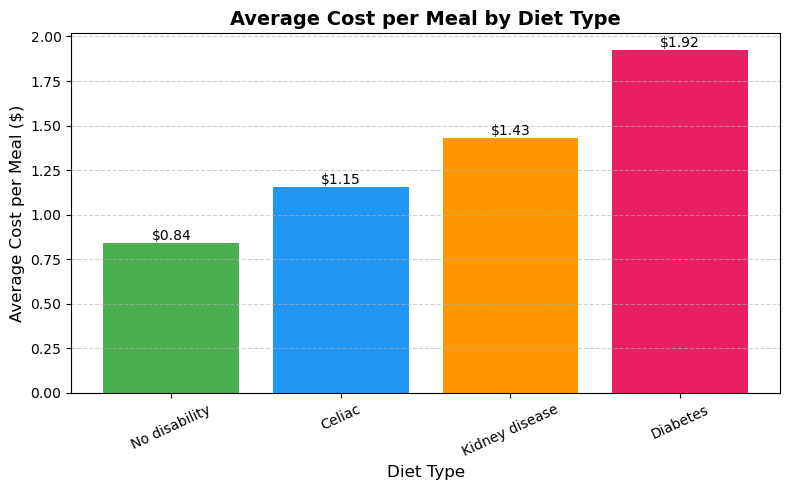

In [21]:
import matplotlib.pyplot as plt

df = results[results["success"] == True].copy()

df["cost_per_meal"] = df["cost_per_day"] / 3

avg_meal_cost = (
    df.groupby("disability")["cost_per_meal"]
    .mean()
    .sort_values()
)

colors = ["#4CAF50", "#2196F3", "#FF9800", "#E91E63"]

plt.figure(figsize=(8,5))
bars = plt.bar(avg_meal_cost.index, avg_meal_cost.values, color=colors)

plt.title("Average Cost per Meal by Diet Type", fontsize=14, weight='bold')
plt.xlabel("Diet Type", fontsize=12)
plt.ylabel("Average Cost per Meal ($)", fontsize=12)

plt.xticks(rotation=25)
plt.grid(axis='y', linestyle='--', alpha=0.6)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f"${height:.2f}",
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

The bar graph shows that the diet to fulfill the dietary restrictions, including minimum nutrition suggestions, upper limit on specific nutrition like sugar and carbohydrate, has the highest cost, more than double the cost for no disability diet. Diets for individuals with diabetes are also relatively expensive because their higher fiber requirements require greater consumption of vegetables and other fiber-rich foods.

## Significance of this Project:
This project highlights how medical dietary restrictions can significantly increase the cost of maintaining a nutritionally adequate diet. The results suggest that individuals with certain health conditions, such as those requiring dialysis or managing diabetes, may face substantially higher food costs simply to meet recommended nutritional guidelines. These findings are important because they illustrate how dietary recommendations that are medically necessary may also create financial burdens, potentially affecting food accessibility and health outcomes. By quantifying the cost differences across dietary needs, the project provides insight into the economic challenges faced by people with medical conditions and underscores the importance of considering affordability when developing dietar
y guidelines, healthcare policies, and nutrition assistance programs.